https://huggingface.co/abenzerps/Qwen-Image-2.1-Uncensored-GGUF

https://comfy.yellorn.com/qwen-image-2-1-uncensored-comfyui/

In [ ]:
#@title Install Qwen-Image-2.1-Uncensored-GGUF

root_path = "/content"  # @param ["/content", "/kaggle/working"]

# ============================================================
# CLONE MAIN REPO
# ============================================================

%cd $root_path

!rm -rf $root_path/Qwen-Image-2.1-Uncensored-GGUF-Colab
!git clone https://github.com/NeuralFalconYT/Qwen-Image-2.1-Uncensored-GGUF-Colab.git


# ============================================================
# INSTALL COMFYUI
# ============================================================

!rm -rf $root_path/ComfyUI
!git clone https://github.com/comfyanonymous/ComfyUI

%cd $root_path/ComfyUI

# PIN_COMMIT = "3c8456223c5f6a41af7d99219b391c8c58acb552"  # Fixed version
PIN_COMMIT = ""  # Latest version

if PIN_COMMIT:
    !git fetch --all -q
    !git reset --hard {PIN_COMMIT}


# ============================================================
# INSTALL COMFYUI REQUIREMENTS
# ============================================================

!pip install -r requirements.txt


# ============================================================
# INSTALL CUSTOM NODES
# ============================================================

%cd $root_path/ComfyUI/custom_nodes

!git clone https://github.com/leejet/ComfyUI-GGUF.git
# !git clone https://github.com/pollockjj/ComfyUI-MultiGPU.git

!pip install -r ./ComfyUI-GGUF/requirements.txt

!pip install gradio==6.26.0


# ============================================================
# MODEL DOWNLOADS
# ============================================================

!apt -y install -qq aria2

# Qwen Image 2.1 UC Q4_K_M GGUF ~4.6 GB
!aria2c \
    --console-log-level=error \
    -c -x 16 -s 16 -k 1M \
    https://huggingface.co/abenzerps/Qwen-Image-2.1-Uncensored-GGUF/resolve/main/qwen-image-2.1-UC-Q4_K_M.gguf \
    -d /content/ComfyUI/models/diffusion_models \
    -o qwen-image-2.1-UC-Q4_K_M.gguf


# Qwen3-VL 8B W4A8 Heretic Text Encoder ~4.8 GB
!aria2c \
    --console-log-level=error \
    -c -x 16 -s 16 -k 1M \
    https://huggingface.co/pottokao/Qwen-Image-2.1-Text-Encoder-Heretic-W4A8/resolve/main/qwen3vl_8b_w4a8_heretic.safetensors \
    -d /content/ComfyUI/models/text_encoders/ \
    -o qwen3vl_8b_w4a8_heretic.safetensors


# Qwen Image 2.1 VAE BF16 ~676 MB
!aria2c \
    --console-log-level=error \
    -c -x 16 -s 16 -k 1M \
    https://huggingface.co/abenzerps/Qwen-Image-2.1-Uncensored-GGUF/resolve/main/vae/qwen_image_2.1_vae_bf16.safetensors \
    -d /content/ComfyUI/models/vae/ \
    -o qwen_image_2.1_vae_bf16.safetensors


# ============================================================
# FINISHED SOUND
# ============================================================

from IPython.display import clear_output, Audio, display

clear_output()

display(
    Audio(
        "https://raw.githubusercontent.com/KoboldAI/KoboldAI-Client/main/colab/silence.m4a",
        autoplay=True,
    )
)

In [ ]:
#@title Gradio Web APP
root_path = "/content"  # @param ["/content", "/kaggle/working"]
%cd $root_path/Qwen-Image-2.1-Uncensored-GGUF-Colab
!python webui.py

In [ ]:
#@title Colab Cell Model Load
root_path = "/content"  # @param ["/content", "/kaggle/working"]
%cd $root_path/Qwen-Image-2.1-Uncensored-GGUF-Colab
import qwen_text_to_image as qwen
await qwen.load_model()

/content/Qwen-Image-2.1-Uncensored-GGUF-Colab
GPU DETECTION
GPU count: 1
GPU 0: Tesla T4 | 14.56 GB

Device plan:
  UNET : cuda:0
  CLIP : cuda:0
  VAE  : cuda:0


WARNING WARNING WARNING
If you are on nvidia 20 series and above it is required that you update your pytorch to cu130 or higher.


This issue might be caused by new missing dependencies added the last time you updated ComfyUI.



Loading GGUF UNET on cuda:0...
✅ UNET loaded via UnetLoaderGGUF -> cuda:0

Loading text encoder on cuda:0...
✅ CLIP loaded via CLIPLoader -> cuda:0

Loading VAE on cuda:0...
✅ VAE loaded via VAELoader -> cuda:0

🔥 QWEN IMAGE 2.1 READY
Reported load devices:
  UNET : cuda:0
  CLIP : cuda:0
  VAE  : cuda:0

After model load
GPU 0 | Tesla T4 | allocated=5.91 GB | reserved=6.32 GB | total=14.56 GB


{'loaded': True,
 'already_loaded': False,
 'devices': {'unet': 'cuda:0', 'clip': 'cuda:0', 'vae': 'cuda:0'},
 'gpus': [{'id': 0,
   'name': 'Tesla T4',
   'total_gb': 14.56317138671875,
   'allocated_gb': 5.9140424728393555,
   'reserved_gb': 6.3203125}]}

QWEN IMAGE 2.1 GENERATION
Size     : 640x640
Steps    : 20
CFG      : 2.2
Sampler  : euler
Scheduler: simple
Seed     : 5741229
Devices  : {'unet': 'cuda:0', 'clip': 'cuda:0', 'vae': 'cuda:0'}

Encoding prompt...
Sampling 640x640...


  0%|          | 0/20 [00:00<?, ?it/s]

Decoding...

✅ DONE
Saved : /content/saved_images/a_girl_looking_like_a_boss_cinematic_35857ee38f_5741229.png
Saved: /content/saved_images/a_girl_looking_like_a_boss_cinematic_35857ee38f_5741229.png
Seed : 5741229
Size : 640 x 640


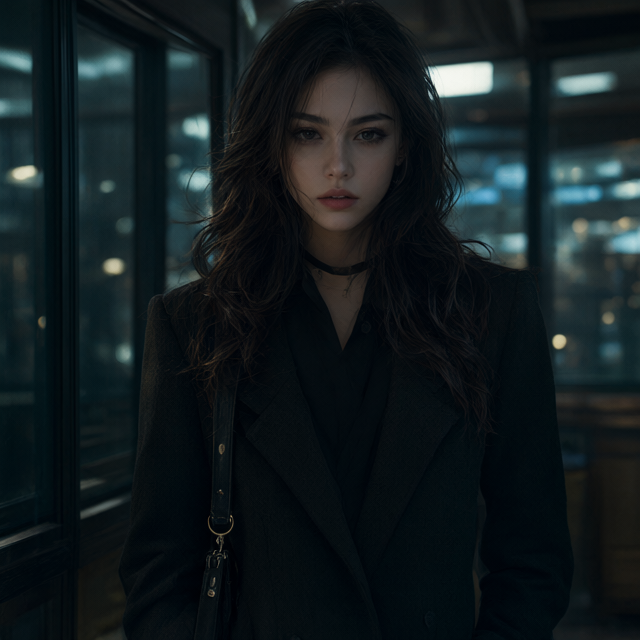

In [ ]:
# @title Generate Qwen Image

from IPython.display import display
import re

prompt = "a girl  looking like a boss cinematic"  # @param {type:"string"}

negative_prompt = "blurry, low quality,"  # @param {type:"string"}

aspect_ratio = "640x640 ( 1:1 )"  # @param ["640x640 ( 1:1 )", "672x512 ( 9:7 )", "512x672 ( 7:9 )", "704x528 ( 4:3 )", "528x704 ( 3:4 )", "720x480 ( 3:2 )", "480x720 ( 2:3 )", "768x432 ( 16:9 )", "432x768 ( 9:16 )", "768x336 ( 21:9 )", "336x768 ( 9:21 )"]

steps = 20  # @param {type:"integer"}

cfg = 2.2  # @param {type:"number"}

denoise = 1.0  # @param {type:"number"}

sampler_name = "euler"  # @param ["euler", "euler_ancestral", "heun", "ddim", "dpmpp_2m", "dpmpp_2m_sde"]

scheduler = "simple"  # @param ["simple", "normal", "karras", "exponential", "sgm_uniform"]

random_seed = True  # @param {type:"boolean"}

seed = 123456  # @param {type:"integer"}

cleanup_after = True  # @param {type:"boolean"}


# ============================================================
# PARSE SIZE
# ============================================================

match = re.match(r"(\d+)x(\d+)", aspect_ratio)

width = int(match.group(1))
height = int(match.group(2))


# ============================================================
# GENERATE
# ============================================================

result = qwen.generate_image(
    prompt=prompt,
    negative_prompt=negative_prompt,
    width=width,
    height=height,
    steps=steps,
    cfg=cfg,
    sampler_name=sampler_name,
    scheduler=scheduler,
    denoise=denoise,
    seed=None if random_seed else seed,
    output_dir="/content/saved_images",
    cleanup_after=cleanup_after,
)


# ============================================================
# RESULT
# ============================================================

print("Saved:", result["path"])
print("Seed :", result["seed"])
print("Size :", result["width"], "x", result["height"])

display(result["image"])

In [ ]:
#@title Downlaod Full Image
from google.colab import files
files.download(result["path"])